In [1]:
from lifelines import CoxPHFitterfrom lifelines import CoxTimeVaryingFitterfrom lifelines import KaplanMeierFitterimport matplotlib.pyplot as pltimport numpy as npimport pandas as pd

In [3]:
df = pd.read_csv("/content / directed_dyadic_war.csv")df["war_start"] = pd.to_datetime(df[["warstrtyr", "warstrtmnth", "warstrtday"]].astype(str).agg("-".join, axis = 1),errors="coerce",)df["war_end"] = pd.to_datetime(df[["warendyr", "warendmnth", "warenday"]].astype(str).agg("-".join, axis = 1),errors="coerce",)df["war_duration_days"] = (df["war_end"] - df["war_start"]).dt.daysdf.to_csv("directed_dyadic_war_cleaned.csv", index = False)

In [3]:
# Prepare dataset for Cox modelcox_df = df[["war_duration_days", "war_end", "warolea"]].copy()# Binary event indicator: assume all wars ended, so event observed = 1cox_df["event_observed"] = 1# Encode warolea as categoricalcox_df["warolea"] = cox_df["warolea"].astype("category")# Drop rows with missing duration or rolecox_df = cox_df.dropna(subset=["war_duration_days", "warolea"])# Create dummy variables for categorical waroleacox_df = pd.get_dummies(cox_df, columns=["warolea"], drop_first = True)# Fit Cox Proportional Hazards modelcph = CoxPHFitter()cph.fit(cox_df.drop(columns=["war_end"]),duration_col="war_duration_days",event_col="event_observed",)# Display summary of the Cox modelcph.print_summary()

<lifelines.CoxPHFitter: fitted with 1359 total observations, 0 right-censored observations>
             duration col = 'war_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 1359
number of events observed = 1359
   partial log-likelihood = -8447.49
         time fit was run = 2025-05-16 18:12:51 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
warolea_2  0.14      1.15      0.08           -0.02            0.30                0.98                1.34
warolea_3 -0.01      0.99      0.08           -0.16            0.14                0.86                1.15
warolea_4  0.12      1.12      0.08           -0.03            0.26                0.97                1.30

           cmp to     z    p  -log2(p)
covariate                             
warolea_2    0.00  1.76 0.08      3.69
warolea_3    0.00 -0.10 0.92      0.12
warolea_4    0.00  1.52 0.13      2.97
---
Concordance = 0.46
Partial AIC = 16900.98
log-likelihood ratio test = 5.09 on 3 df
-log2(p) of ll-ratio test = 2.60

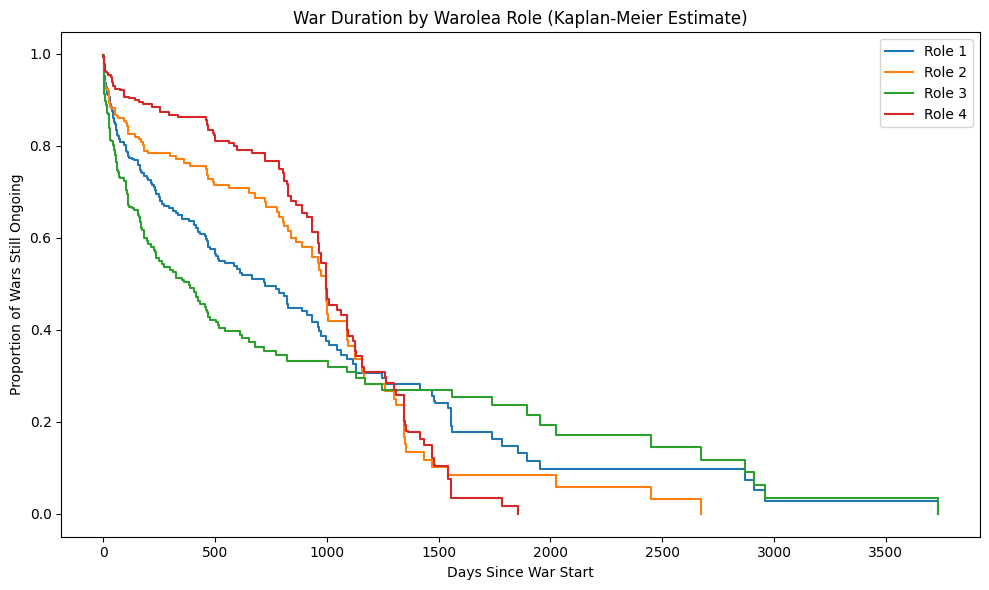

In [4]:
# Prepare the data againkm_df = df[["war_duration_days", "warolea"]].copy()km_df["event_observed"] = 1km_df = km_df.dropna(subset=["war_duration_days", "warolea"])# Set up plotplt.figure(figsize=(10, 6))kmf = KaplanMeierFitter()# Plot KM curve for each warolea groupfor role in sorted(km_df["warolea"].dropna().unique()):mask = km_df["warolea"] == rolekmf.fit(km_df.loc[mask, "war_duration_days"],event_observed = km_df.loc[mask, "event_observed"],label = f"Role {int(role)}",)kmf.plot_survival_function(ci_show = False)# Style the plotplt.title("War Duration by Warolea Role (Kaplan - Meier Estimate)")plt.xlabel("Days Since War Start")plt.ylabel("Proportion of Wars Still Ongoing")plt.tight_layout()plt.savefig("km_warolea_survival.png")plt.show()

In [5]:
# Prepare datacox_df = df[["war_duration_days", "batdths", "statea", "stateb"]].copy()cox_df["event_observed"] = 1cox_df = cox_df.dropna()# Fit Cox modelcph = CoxPHFitter()cph.fit(cox_df, duration_col="batdths", event_col="event_observed")# Show summarycph.print_summary()

<lifelines.CoxPHFitter: fitted with 1343 total observations, 0 right-censored observations>
             duration col = 'batdths'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 1343
number of events observed = 1343
   partial log-likelihood = -8160.53
         time fit was run = 2025-05-16 18:13:01 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
war_duration_days -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
statea             0.00      1.00      0.00            0.00            0.00                1.00                1.00
stateb             0.00      1.00      0.00            0.00            0.00                1.00                1.00

                   cmp to      z      p  -log2(p)
covariate                                        
war_duration_days    0.00 -16.76 <0.005    207.06
statea               0.00   7.45 <0.005     43.32
stateb               0.00   7.47 <0.005     43.52
---
Concordance = 0.70
Partial AIC = 16327.06
log-likelihood ratio test = 348.32 on 3 df
-log2(p) of ll-ratio test = 247.36

<Figure size 1000x600 with 0 Axes>

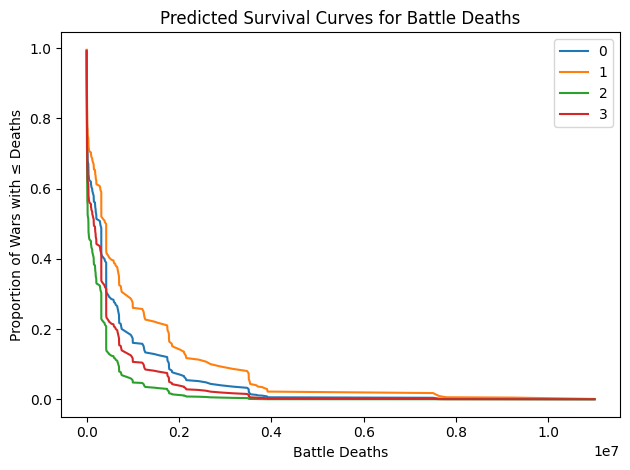

In [6]:
# Recreate the fitted model (assumes df is already loaded and clean)cox_df = df[["batdths", "war_duration_days", "statea", "stateb"]].copy()cox_df["event_observed"] = 1cox_df = cox_df.dropna()cph = CoxPHFitter()cph.fit(cox_df, duration_col="batdths", event_col="event_observed")# Create prediction scenariosscenarios = pd.DataFrame([{"war_duration_days": 100, "statea": 220, "stateb": 230},{"war_duration_days": 500, "statea": 220, "stateb": 230},{"war_duration_days": 100, "statea": 365, "stateb": 640},{"war_duration_days": 500, "statea": 365, "stateb": 640},])# Plot survival curves for these scenariosplt.figure(figsize=(10, 6))cph.predict_survival_function(scenarios).plot()plt.title("Predicted Survival Curves for Battle Deaths")plt.xlabel("Battle Deaths")plt.ylabel("Proportion of Wars with ≤ Deaths")plt.tight_layout()plt.show()

In [7]:
cph.check_assumptions(cox_df, p_value_threshold = 0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1343 total observations, 0 right-censored observations>
         test_name = proportional_hazard_test

---
                        test_statistic      p  -log2(p)
statea            km              9.18 <0.005      8.67
                  rank            9.75 <0.005      9.12
stateb            km              8.87 <0.005      8.43
                  rank            8.33 <0.005      8.00
war_duration_days km            351.16 <0.005    257.87
                  rank          343.74 <0.005    252.50



1. Variable 'war_duration_days' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'war_duration_days' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'war_duration_days' using pd.cut, and then specify it in
`strata=['war_duration_days', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'statea' failed the non-proportional test: p-value is 0.0018.

   Advice 1: the functional form of the variable 'statea' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] belo

[]

<Axes: >

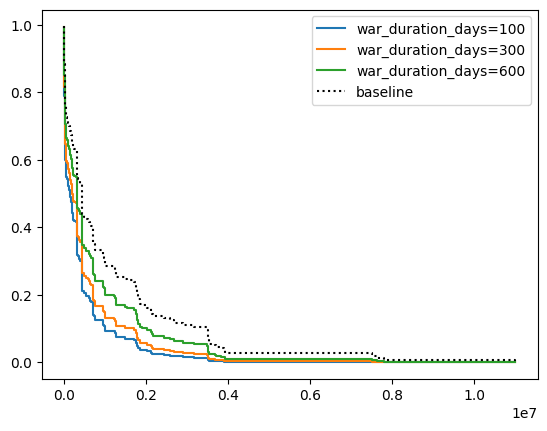

In [8]:
cph.plot_partial_effects_on_outcome(covariates="war_duration_days", values=[100, 300, 600])

In [1]:
# Assume df is your original DataFrame with one row per war# Create time - varying format: one row per (war, time interval)# Define function to expand war rows into time intervalsdef expand_war_rows(df, duration_col="batdths", interval = 30):records = []for idx, row in df.iterrows():duration = int(row[duration_col])if np.isnan(duration) or duration <= 0:continuesteps = int(np.ceil(duration / interval))for i in range(steps):start = i * intervalstop = min((i + 1) * interval, duration)event = int(stop == duration)records.append({"id": idx,"start": start,"stop": stop,"event": event,"war_duration_days": row["war_duration_days"],"statea": row["statea"],"stateb": row["stateb"],"month_index": i + 1,  # or log(stop), time since start})return pd.DataFrame(records)# Apply the transformationtv_df = expand_war_rows(df, duration_col="batdths", interval = 30)tv_df = tv_df.dropna()# Optional: encode states as categories (or leave numeric if not many)tv_df["statea"] = tv_df["statea"].astype("category")tv_df["stateb"] = tv_df["stateb"].astype("category")# Convert to dummies if categoricaltv_df = pd.get_dummies(tv_df, columns=["statea", "stateb"], drop_first = True)# Fit time - varying Cox modelctv = CoxTimeVaryingFitter()ctv.fit(tv_df, id_col="id", start_col="start", stop_col="stop", event_col="event")ctv.print_summary()

NameError: name 'df' is not defined

In [4]:
MAX_STEPS = 50  # cap to avoid long wars creating massive rowsdef expand_war_rows(df, duration_col="batdths", interval = 30):records = []for idx, row in df.iterrows():try:duration = int(row[duration_col])except:continueif duration <= 0 or np.isnan(duration):continuesteps = min(MAX_STEPS, int(np.ceil(duration / interval)))for i in range(steps):start = i * intervalstop = min((i + 1) * interval, duration)event = int(stop == duration)records.append({"id": idx,"start": start,"stop": stop,"event": event,"war_duration_days": row["war_duration_days"],"statea": row["statea"],"stateb": row["stateb"],"month_index": i + 1,})return pd.DataFrame(records)df_subset = df[df["batdths"] < 20000].copy()tv_df = expand_war_rows(df_subset, duration_col="batdths", interval = 30)

In [5]:
tv_df.head()

,id,start,stop,event,war_duration_days,statea,stateb,month_index
0,0,0,30,0,176.0,220,230,1
1,0,30,60,0,176.0,220,230,2
2,0,60,90,0,176.0,220,230,3
3,0,90,120,0,176.0,220,230,4
4,0,120,150,0,176.0,220,230,5


In [7]:
ctv = CoxTimeVaryingFitter()ctv.fit(tv_df, id_col="id", start_col="start", stop_col="stop", event_col="event")ctv.print_summary()

LinAlgError: Matrix is singular.

In [8]:
# Drop high - cardinality dummies (optional)cols_to_drop = [colfor col in tv_df.columnsif col.startswith("statea_") or col.startswith("stateb_")]tv_df = tv_df.drop(columns = cols_to_drop)

In [9]:
tv_df_reduced = tv_df[["id", "start", "stop", "event", "war_duration_days", "month_index"]].copy()

In [10]:
ctv = CoxTimeVaryingFitter(penalizer = 0.01)ctv.fit(tv_df_reduced, id_col="id", start_col="start", stop_col="stop", event_col="event")ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 16306 periods, 354 subjects, 70 events>
         event col = 'event'
         penalizer = 0.01
number of subjects = 354
 number of periods = 16306
  number of events = 70
partial log-likelihood = -401.22
  time fit was run = 2025-05-16 18:39:54 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
war_duration_days -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
month_index       -0.00      1.00      0.01           -0.01            0.01                0.99                1.01

                   cmp to     z    p  -log2(p)
covariate                                     
war_duration_days    0.00 -2.12 0.03      4.87
month_index          0.00 -0.00 1.00      0.00
---
Partial AIC = 806.43
log-likelihood ratio test = 4.63 on 2 df
-log2(p) of ll-ratio test = 3.34

In [11]:
ctv.plot_partial_effects_on_outcome(covariates="war_duration_days", values=[100, 300, 600])plt.title("Effect of War Duration on Survival Curve (Battle Death Hazard)")plt.xlabel("Battle Deaths")plt.ylabel("Survival Probability")plt.tight_layout()plt.show()

AttributeError: 'CoxTimeVaryingFitter' object has no attribute 'plot_partial_effects_on_outcome'

In [12]:
# Create hypothetical subjects for predictionscenarios = pd.DataFrame([{"id": 0,"start": 0,"stop": 1,"event": 0,"war_duration_days": 100,"month_index": 1,},{"id": 1,"start": 0,"stop": 1,"event": 0,"war_duration_days": 300,"month_index": 1,},{"id": 2,"start": 0,"stop": 1,"event": 0,"war_duration_days": 600,"month_index": 1,},])# Extend each scenario over time (e.g., 1 to 40 intervals)frames = []for idx, row in scenarios.iterrows():for t in range(1, 40):r = row.copy()r["start"] = t - 1r["stop"] = tr["month_index"] = tframes.append(r)scenario_df = pd.DataFrame(frames)# Predict survival functionsurv = ctv.predict_survival_function(scenario_df, id_col="id")# Plotplt.figure(figsize=(10, 6))for col in surv.columns:plt.plot(surv.index,surv[col],label = f"Duration = {int(scenarios.loc[col, 'war_duration_days'])}",)plt.title("Predicted Survival Curves by War Duration")plt.xlabel("Time Interval (months)")plt.ylabel("Probability War Has Not Reached Total Deaths")plt.legend()plt.tight_layout()plt.show()

AttributeError: 'CoxTimeVaryingFitter' object has no attribute 'predict_survival_function'

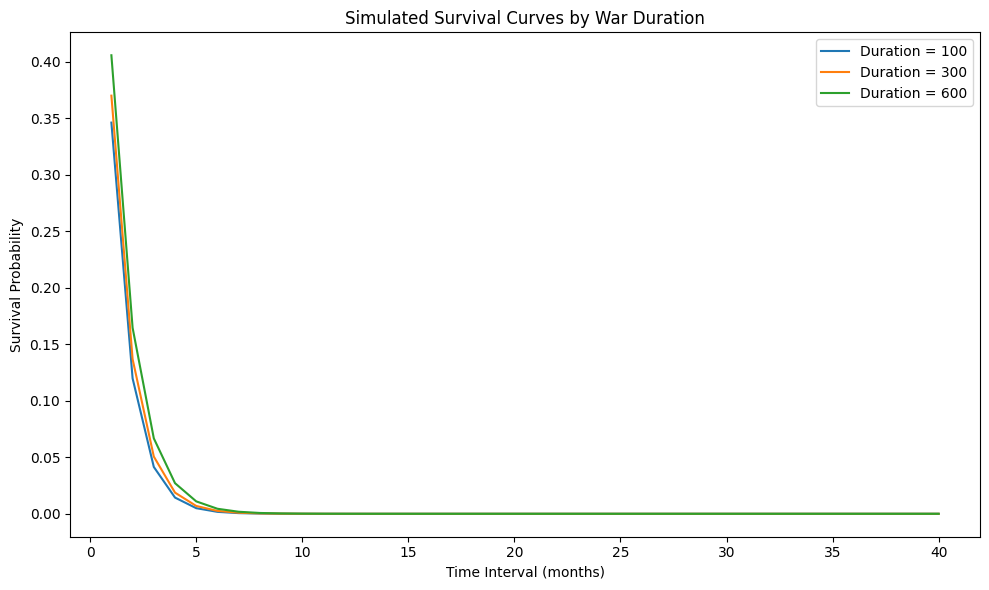

In [13]:
# Create example subjects at time t = 0durations = [100, 300, 600]all_surv = []for i, d in enumerate(durations):subject_rows = []for t in range(1, 41):  # simulate up to 40 monthssubject_rows.append({"id": i,"start": t - 1,"stop": t,"event": 0,"war_duration_days": d,"month_index": t,})subject_df = pd.DataFrame(subject_rows)subject_df["hazard"] = ctv.predict_partial_hazard(subject_df)cum_hazard = subject_df["hazard"].cumsum()surv = np.exp(-cum_hazard)all_surv.append((subject_df["stop"], surv, f"Duration = {d}"))# Plot simulated survival curvesplt.figure(figsize=(10, 6))for t, s, label in all_surv:plt.plot(t, s, label = label)plt.title("Simulated Survival Curves by War Duration")plt.xlabel("Time Interval (months)")plt.ylabel("Survival Probability")plt.legend()plt.tight_layout()plt.show()